In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.odr import Model, Data, RealData, ODR
from scipy import stats
import warnings

warnings.simplefilter(action="ignore", category=pd.errors.SettingWithCopyWarning)

In [2]:
data_d = "/home/lucytian/data/1_Single_Cell_PRS/2_cV2F/mvp_afr_0.9_0.01/20231221/406k_geno_v2_UKB_18PCs/fit_w_val"
traits = ['INI30120', 'INI50030700', 'INI1003063', 'INI20030780']
tissue_trait_dict = {'INI50030700': 'KIDNEY', 'INI1003063': 'LUNG', 'INI20030780': 'LIVER', 'INI30120' : 'BLOOD'}
name_trait_dict = {'INI30120' : 'Lymphocyte Count', 'INI50030700': 'eGFR', 'INI1003063': 'FEV1/FVC Ratio', 'INI20030780': 'LDL-C'}

In [3]:
dfs = []

for tr in traits:

    if tr == "INI20030780":
        tissue_path   = f"{data_d}/{tissue_trait_dict[tr]}/{tr}/exclude_APOE/snpnet.eval.tsv.gz"
        baseline_path = f"{data_d}/baseline/{tr}/exclude_APOE/snpnet.eval.tsv.gz"
        impact_path   = f"{data_d}/IMPACT_{tr}/{tr}/exclude_APOE/snpnet.eval.tsv.gz"
    else:
        tissue_path   = f"{data_d}/{tissue_trait_dict[tr]}/{tr}/snpnet.eval.tsv.gz"
        baseline_path = f"{data_d}/baseline/{tr}/snpnet.eval.tsv.gz"
        impact_path   = f"{data_d}/IMPACT_{tr}/{tr}/snpnet.eval.tsv.gz"

    found_any = False

    # 🔹 Tissue
    if os.path.exists(tissue_path):
        tissue = pd.read_csv(tissue_path, sep='\t', compression='gzip')
        tissue['annot'] = 'PRISM'
        dfs.append(tissue)
        found_any = True
    else:
        print(f"[MISSING] Tissue file for {tr}")

    # 🔹 Baseline
    if os.path.exists(baseline_path):
        baseline = pd.read_csv(baseline_path, sep='\t', compression='gzip')
        baseline['annot'] = 'baseline_LD'
        dfs.append(baseline)
        found_any = True
    else:
        print(f"[MISSING] Baseline file for {tr}")

    # 🔹 Impact
    if os.path.exists(impact_path):
        impact = pd.read_csv(impact_path, sep='\t', compression='gzip')
        impact['annot'] = 'IMPACT'
        dfs.append(impact)
        found_any = True
    else:
        print(f"[MISSING] IMPACT file for {tr}")

    if not found_any:
        print(f"[SKIP TRAIT] No files found for {tr}")

[MISSING] IMPACT file for INI50030700


In [4]:
all_df = pd.concat(dfs)
test = all_df[(all_df['population'] == 'Afr') & (all_df['split'] == 'test') & (all_df['model'] == 'PGS')]
test['annot'] = [
    'PRISM cV2F',
    'Baseline-LD\ncV2F',
    'IMPACT',
    'PRISM cV2F',
    'Baseline-LD\ncV2F',
    'PRISM cV2F',
    'Baseline-LD\ncV2F',
    'IMPACT',
    'PRISM cV2F',
    'Baseline-LD\ncV2F',
    'IMPACT',
]

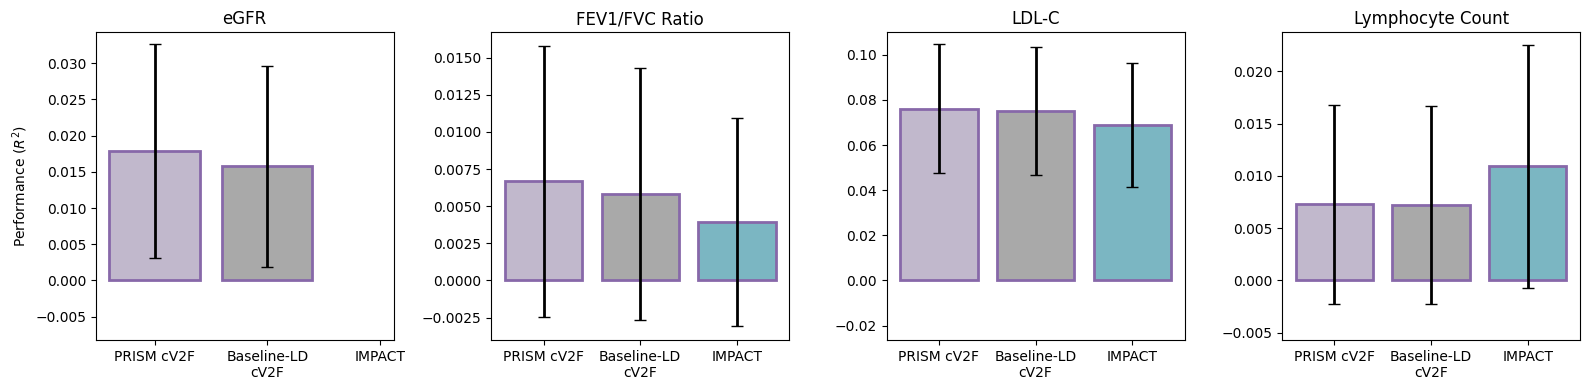

In [5]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# === Plotting settings ===
order = ['PRISM cV2F',
         'Baseline-LD\ncV2F',
         'IMPACT']
colors = ["#c0b5cf", "#A9A9A9", "#6fbece"]

# --- force 1 row, 4 columns ---
ncols = 4
nrows = 1

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4))
axes = axes.flatten()

# === Generate subplots ===
for i, (code, trait) in enumerate(tissue_trait_dict.items()):
    ax = axes[i]
    df_trait = test[test["#response"] == code].copy()

    if df_trait.empty:
        ax.set_visible(False)
        continue

    # Compute error bars
    df_trait["err_lower"] = df_trait["eval"] - df_trait["l_eval"]
    df_trait["err_upper"] = df_trait["u_eval"] - df_trait["eval"]

    # Reindex to full order
    df_indexed = (
        df_trait
        .set_index("annot")
        .reindex(order)
        .reset_index()
    )

    sns.barplot(
        data=df_indexed,
        x="annot", y="eval",
        order=order,
        palette=colors,
        ax=ax,
        capsize=0,
        edgecolor="#8768a9",
        linewidth=2
    )

    ax.errorbar(
        x=range(len(order)),
        y=df_indexed["eval"].values,
        yerr=[df_indexed["err_lower"].values, df_indexed["err_upper"].values],
        fmt='none',
        ecolor='black',
        elinewidth=2,
        capsize=4
    )

    # --- KEY: force same baseline ---
    ymin, ymax = ax.get_ylim()
    #ax.set_ylim(0, ymax)   # align all plots at 0

    ax.set_title(name_trait_dict[code], fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Performance ($R^2$)" if i == 0 else "")
    ax.tick_params(axis='x', labelrotation=0)

# Hide unused axes if fewer than 4 traits
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

    
# --- Step 1: get original limits ---
ylims = [ax.get_ylim() for ax in axes[:len(tissue_trait_dict)]]

# --- Step 2: compute zero positions ---
zero_positions = [
    (0 - ymin) / (ymax - ymin)
    for ymin, ymax in ylims
]

# --- Step 3: choose common zero position
target = max(zero_positions)  # ensures no cropping of negative side

# --- Step 4: expand each axis to match target ---
for ax, (ymin, ymax), zp in zip(axes, ylims, zero_positions):
    span = ymax - ymin

    # compute required new span so zero aligns at target
    new_span = max(
        (0 - ymin) / target,
        (ymax - 0) / (1 - target)
    )

    new_ymin = 0 - target * new_span
    new_ymax = 0 + (1 - target) * new_span

    ax.set_ylim(new_ymin, new_ymax)
    
    
plt.tight_layout()
#plt.savefig("annot_bar.pdf", bbox_inches="tight")
plt.show()